In [1]:
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import AssignmentI.helper as helper

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import pandas as pd
from scipy.stats import norm
import statsmodels.api as sm
from scipy.stats import t

# Question (a)

## Local Level Model

In [2]:
# -----------------------------
# Local Level model simulation
# y_t = mu_t + eps_t,    eps_t ~ N(0, sigma_eps^2)
# mu_{t+1} = mu_t + eta_t, eta_t ~ N(0, sigma_eta^2)
# -----------------------------

def local_level_data_generation(n, sigma_eps2, sigma_eta2, mu1=0, seed=123):
    np.random.seed(seed)
    sigma_eps = np.sqrt(sigma_eps2)
    sigma_eta = np.sqrt(sigma_eta2)

    eps = np.random.normal(0.0, sigma_eps, size=n)
    eta = np.random.normal(0.0, sigma_eta, size=n)

    # Generate mu_t
    mu = np.empty(n)
    mu[0] = mu1
    for t in range(1, n):
        mu[t] = mu[t-1] + eta[t-1]
    
    # Generate y_t
    y = mu + eps

    return y, mu

### Local Level Model Data Generation

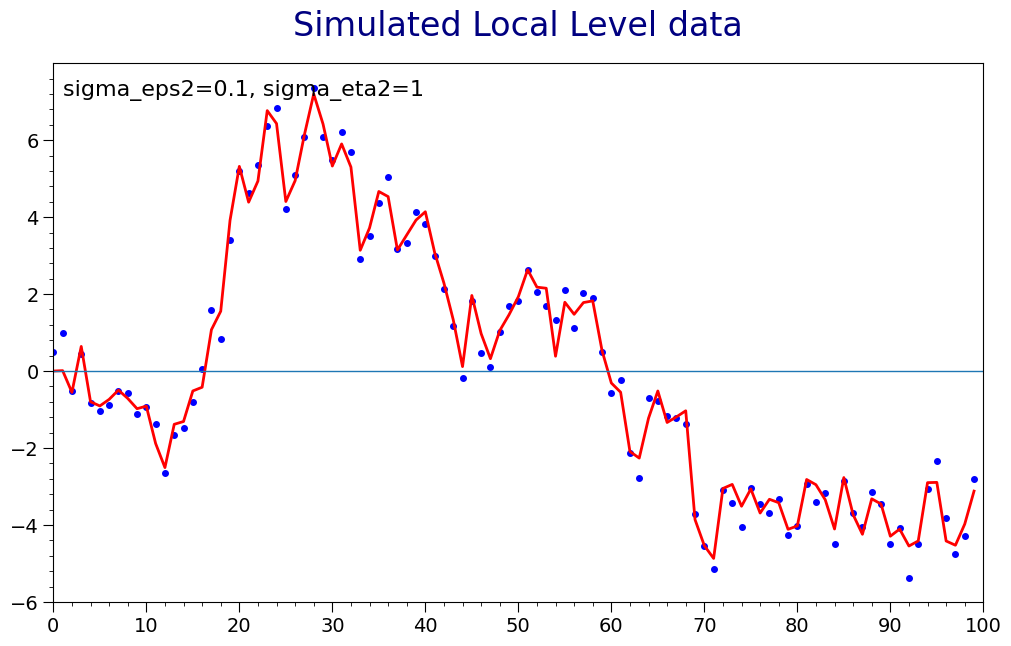

In [3]:
# Plot 
n=100
sigma_eps2_1 = 0.1
sigma_eta2_1 = 1
y1, mu1 = local_level_data_generation(n, sigma_eps2_1, sigma_eta2_1, mu1=0, seed=5473)
x = np.arange(n)

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(x, y1, 'o', markersize=4, color="blue")
ax.plot(x, mu1, '-', linewidth=2, color="red")
ax.axhline(0, linewidth=1)

ax.set_title("Simulated Local Level data", fontsize=24, pad=20, color="navy")
ax.text(0.01, 0.94, f"sigma_eps2={sigma_eps2_1}, sigma_eta2={sigma_eta2_1}",
        transform=ax.transAxes, fontsize=16)

ax.set_xlim(0, n)

ax.xaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_locator(MultipleLocator(2))

ax.xaxis.set_minor_locator(MultipleLocator(2))
ax.yaxis.set_minor_locator(MultipleLocator(0.4))

ax.tick_params(axis='both', which='major', labelsize=14, length=7)
ax.tick_params(axis='both', which='minor', length=3)

plt.show()


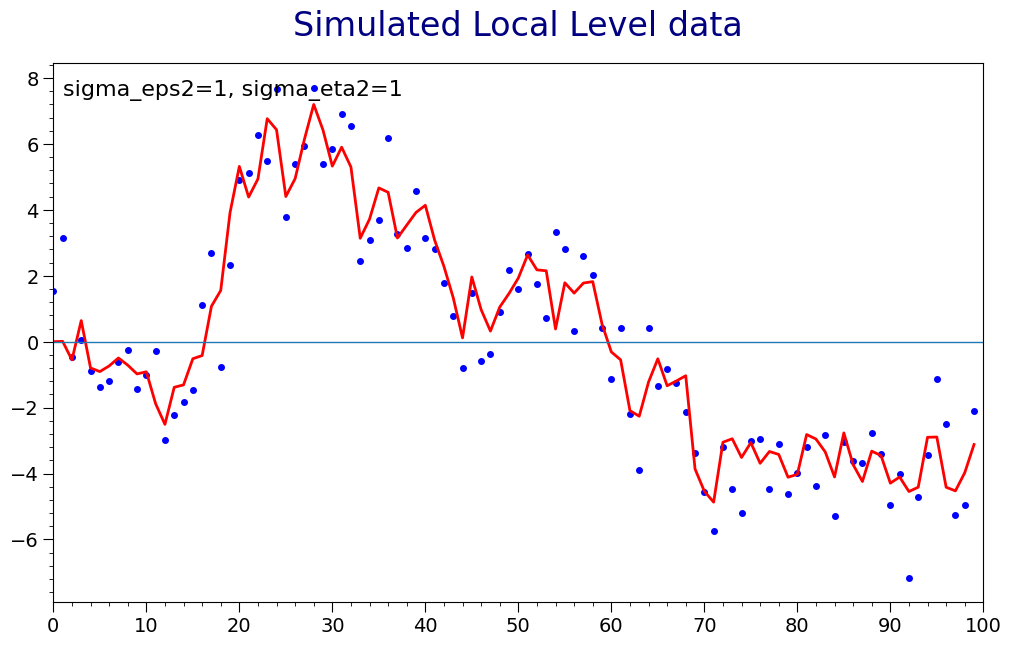

In [4]:
# Plot 
n=100
sigma_eps2_2 = 1
sigma_eta2_2 = 1
y2, mu2 = local_level_data_generation(n, sigma_eps2_2, sigma_eta2_2, mu1=0, seed=5473)
x = np.arange(n)

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(x, y2, 'o', markersize=4, color="blue")
ax.plot(x, mu2, '-', linewidth=2, color="red")
ax.axhline(0, linewidth=1)

ax.set_title("Simulated Local Level data", fontsize=24, pad=20, color="navy")
ax.text(0.01, 0.94, f"sigma_eps2={sigma_eps2_2}, sigma_eta2={sigma_eta2_2}",
        transform=ax.transAxes, fontsize=16)

ax.set_xlim(0, n)

ax.xaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_locator(MultipleLocator(2))

ax.xaxis.set_minor_locator(MultipleLocator(2))
ax.yaxis.set_minor_locator(MultipleLocator(0.4))

ax.tick_params(axis='both', which='major', labelsize=14, length=7)
ax.tick_params(axis='both', which='minor', length=3)

plt.show()

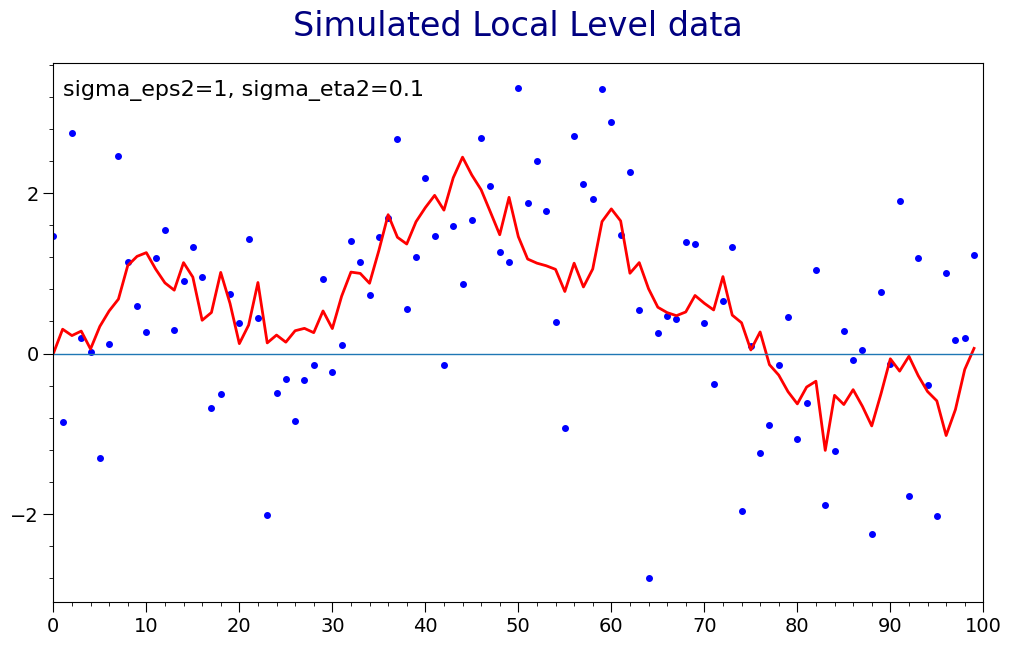

In [5]:
# Plot 
n=100
sigma_eps2_3 = 1
sigma_eta2_3 = 0.1
y3, mu3 = local_level_data_generation(n, sigma_eps2_3, sigma_eta2_3, mu1=0, seed=345)
x = np.arange(n)

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(x, y3, 'o', markersize=4, color="blue")
ax.plot(x, mu3, '-', linewidth=2, color="red")
ax.axhline(0, linewidth=1)

ax.set_title("Simulated Local Level data", fontsize=24, pad=20, color="navy")
ax.text(0.01, 0.94, f"sigma_eps2={sigma_eps2_3}, sigma_eta2={sigma_eta2_3}",
        transform=ax.transAxes, fontsize=16)

ax.set_xlim(0, n)

ax.xaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_locator(MultipleLocator(2))

ax.xaxis.set_minor_locator(MultipleLocator(2))
ax.yaxis.set_minor_locator(MultipleLocator(0.4))

ax.tick_params(axis='both', which='major', labelsize=14, length=7)
ax.tick_params(axis='both', which='minor', length=3)

plt.show()


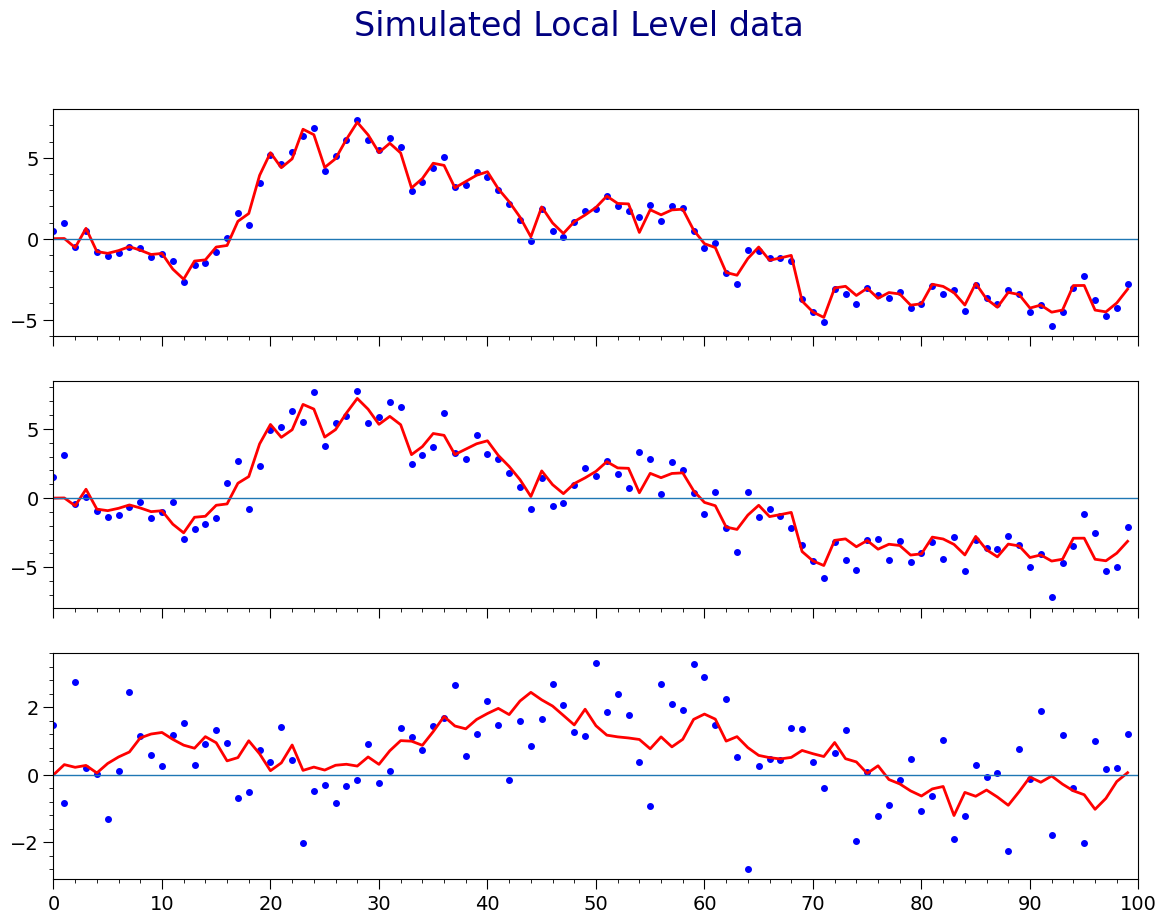

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# ===== plot =====
axes[0].plot(x, y1, 'o', markersize=4, color="blue")
axes[0].plot(x, mu1, '-', linewidth=2, color="red")
axes[0].axhline(0, linewidth=1)

axes[1].plot(x, y2, 'o', markersize=4, color="blue")
axes[1].plot(x, mu2, '-', linewidth=2, color="red")
axes[1].axhline(0, linewidth=1)

axes[2].plot(x, y3, 'o', markersize=4, color="blue")
axes[2].plot(x, mu3, '-', linewidth=2, color="red")
axes[2].axhline(0, linewidth=1)

for ax in axes:
    ax.set_xlim(0, n)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(MultipleLocator(2))
    ax.tick_params(axis='both', which='major', labelsize=14, length=7)
    ax.tick_params(axis='both', which='minor', length=3)

for ax in axes[:2]:
    ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_minor_locator(MultipleLocator(1))

axes[2].yaxis.set_major_locator(MultipleLocator(2))
axes[2].yaxis.set_minor_locator(MultipleLocator(0.4))

fig.suptitle("Simulated Local Level data", fontsize=24, color="navy")

plt.show()


### GasolineSales2 data

In [7]:
def kalman_filter_local_level(y, sigma_eps2, sigma_eta2, a1=0.0, p1=None):

    y = np.asarray(y, dtype=float)
    T = len(y)

    if p1 is None:
        p1 = sigma_eps2 * 1e7

    # allocate
    a_pred = np.zeros(T)   # a_t (one-step-ahead prior mean for mu_t)
    p_pred = np.zeros(T)   # p_t (prior var)
    v = np.zeros(T)        # innovations
    F = np.zeros(T)        # var(innovation)
    K = np.zeros(T)        # Kalman gain
    a_filt = np.zeros(T)   # a_{t|t} filtered mean
    p_filt = np.zeros(T)   # p_{t|t} filtered var

    a_pred[0] = a1
    p_pred[0] = p1

    for t in range(T):
        # update using y_t
        v[t] = y[t] - a_pred[t]
        F[t] = p_pred[t] + sigma_eps2
        K[t] = p_pred[t] / F[t]
        a_filt[t] = a_pred[t] + K[t] * v[t]
        p_filt[t] = K[t]*sigma_eps2

        # predict next
        if t < T - 1:
            a_pred[t + 1] = a_filt[t]
            p_pred[t + 1] = p_filt[t] + sigma_eta2

    return {
        "a_pred": a_pred, "p_pred": p_pred,
        "v": v, "F": F, "K": K,
        "a_filt": a_filt, "p_filt": p_filt
    }

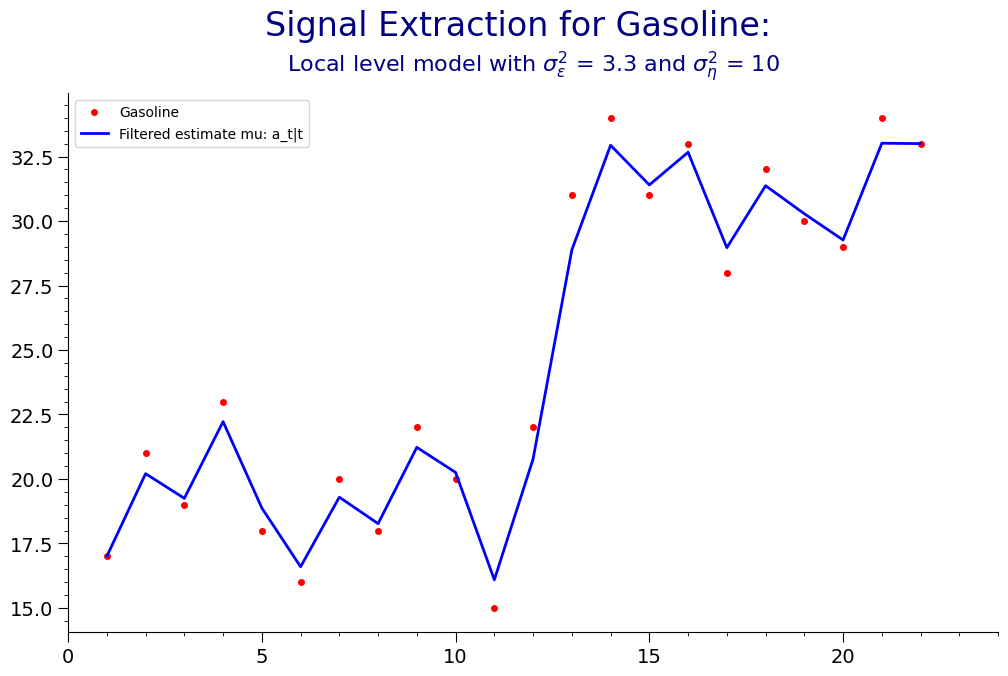

In [8]:
df = pd.read_excel("GasolineSales2.xlsx")
y = df.iloc[:,1]

sigma_eps2 = 3.3
sigma_eta2 = 10

res = kalman_filter_local_level(y, sigma_eps2=sigma_eps2, sigma_eta2=sigma_eta2)
signal = res["a_filt"]

# Plot filtered mu
T = len(y)
x = np.arange(1, T + 1)

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(x, y, 'o', markersize=4, color="red", label="Gasoline")
ax.plot(x, signal, '-', linewidth=2, color="blue", label="Filtered estimate mu: a_t|t")
fig.suptitle("Signal Extraction for Gasoline:", fontsize=24, color="navy", y=1)
ax.set_title(rf"Local level model with $\sigma_\varepsilon^2$ = {sigma_eps2} and $\sigma_\eta^2$ = {sigma_eta2}",
             fontsize=16, color="navy", pad=16)

ax.set_xlim(0, T + 2)

ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.yaxis.set_major_locator(MultipleLocator(2.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.5))

ax.tick_params(axis='both', which='major', labelsize=14, length=7)
ax.tick_params(axis='both', which='minor', length=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.show()

### Observation weights

In [9]:
def local_level_observation_weights(K, t=None):

    K = np.asarray(K, dtype=float)
    T = len(K)
    
    w = np.zeros(T)
    if t is None:
        t = T - 1

    w[0] = K[t]
    # cumulative product term: prod_{m=0}^{j-1}(1 - k_{t-m})
    prod_term = 1.0
    for j in range(1, T):
        prod_term *= (1.0 - K[t- (j-1)])
        w[j] = K[t - j] * prod_term

    return w

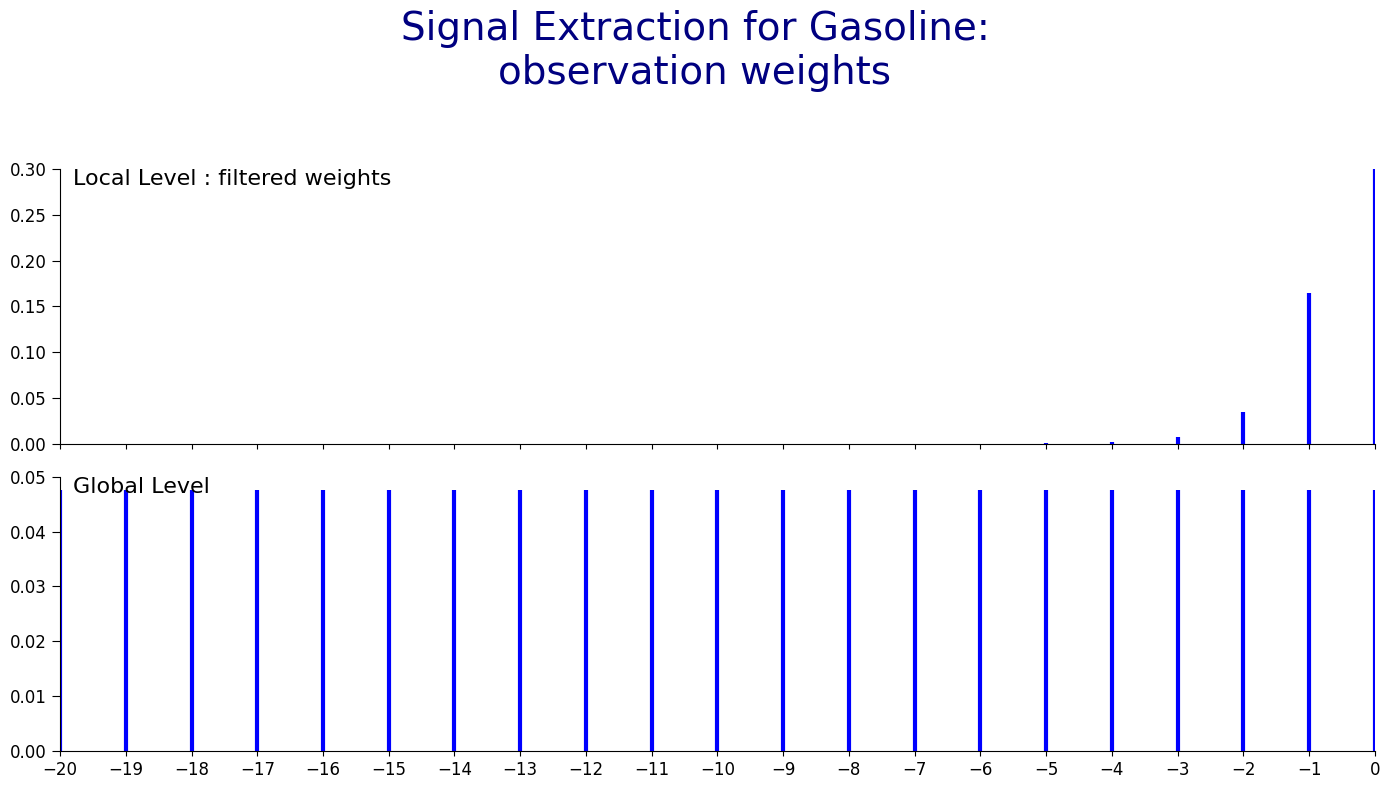

In [10]:
K = res["K"]
L = 20
w_local = local_level_observation_weights(K)
w_global = np.full(L+1, 1.0/(L+1))

# x positions: -L ... 0
lags = np.arange(-L, 1)
w_local_plot = w_local[:L+1][::-1]
w_global_plot = w_global[:L+1][::-1]

# plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Signal Extraction for Gasoline:\nobservation weights",
             fontsize=28, color="navy", y=0.98)

# ---- Top: Local Level filtered weights ----
axes[0].vlines(lags, 0, w_local_plot, color="blue", linewidth=3)
axes[0].set_ylim(0, 0.30)
axes[0].text(0.01, 0.94, "Local Level : filtered weights",
             transform=axes[0].transAxes, fontsize=16)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ---- Bottom: Global Level ----
axes[1].vlines(lags, 0, w_global_plot, color="blue", linewidth=3)
axes[1].set_ylim(0, 0.05)
axes[1].text(0.01, 0.94, "Global Level",
             transform=axes[1].transAxes, fontsize=16)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

axes[1].set_xlim(-L, 0)
axes[1].set_xticks(lags)         
axes[1].tick_params(axis='x', labelsize=12)

for ax in axes:
    ax.tick_params(axis='y', labelsize=12, length=6)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### Local Level Forecasting

In [11]:
def local_level_forecast(a_TT, p_TT, sigma_eps2, sigma_eta2, h=5, alpha=0.05):
    """
    Returns:
        mean[h], lower[h], upper[h], var_y[h]
    For local level:
        mean_{T+h|T} = a_TT
        Var(y_{T+h}|T) = p_TT + h*sigma_eta2 + sigma_eps2
    """
    z = norm.ppf(1 - alpha/2)

    steps = np.arange(1, h+1)
    mean = np.full(h, a_TT)
    var_y = p_TT + steps * sigma_eta2 + sigma_eps2
    se = np.sqrt(var_y)

    lower = mean - z * se
    upper = mean + z * se
    return mean, lower, upper, var_y

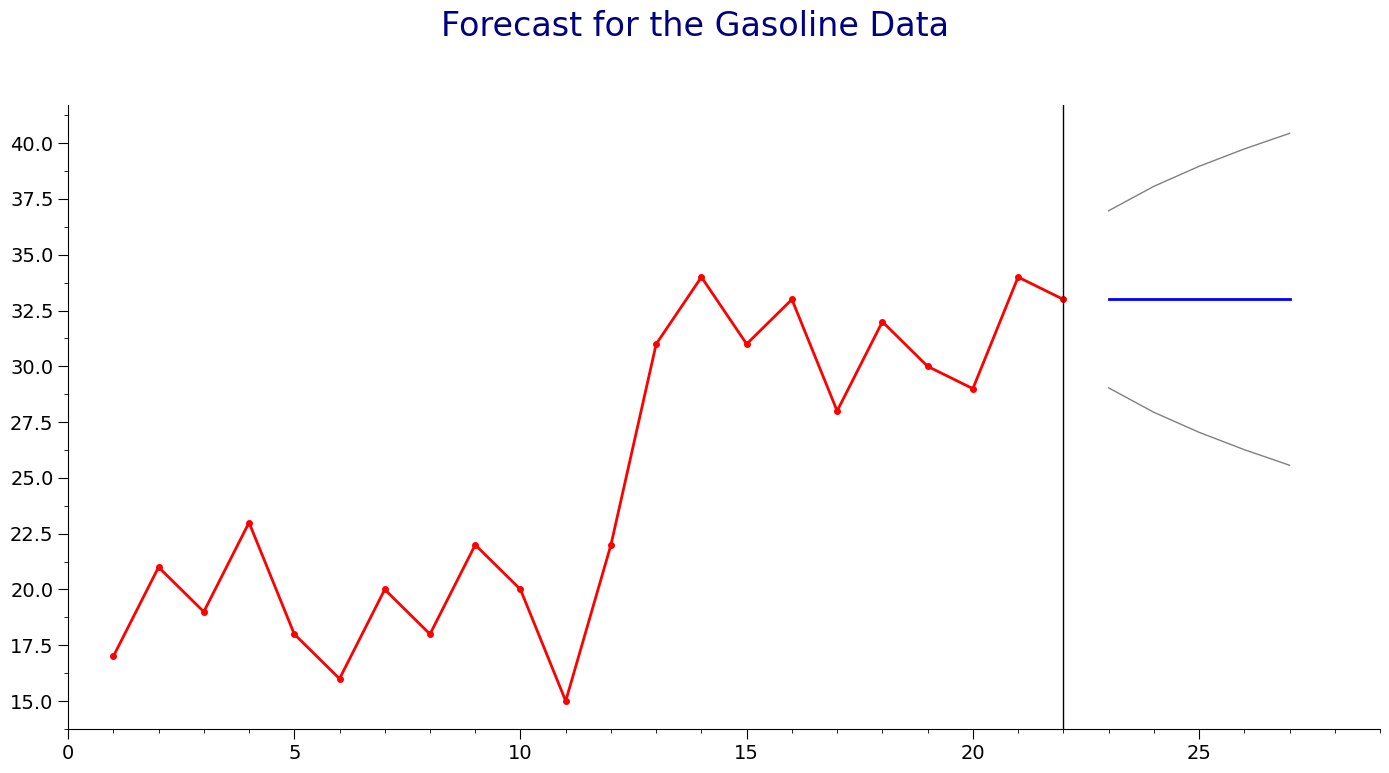

In [12]:
h = 5
a_TT = res["a_filt"][-1]
p_TT = res["p_filt"][-1]
f_mean, f_low, f_up, f_var = local_level_forecast(a_TT, p_TT, sigma_eps2, sigma_eta2, h=h, alpha=0.32)

# plot
T = len(y)
x_data = np.arange(1, T + 1)
x_fcst = np.arange(T + 1, T + h + 1)

fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Forecast for the Gasoline Data", fontsize=24, color="navy", y=0.96)

ax.plot(x_data, y, "-o", color="red", markersize=4, linewidth=2)
ax.axvline(T, color="black", linewidth=1)
# forecast mean
ax.plot(x_fcst, f_mean, color='blue', linewidth=2)
# CI bounds
ax.plot(x_fcst, f_up, color='grey', linewidth=1)
ax.plot(x_fcst, f_low, color='grey', linewidth=1)

ax.set_xlim(0, T + h + 2)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.yaxis.set_major_locator(MultipleLocator(2.5))
ax.yaxis.set_minor_locator(MultipleLocator(1.25))

ax.tick_params(axis='both', which='major', labelsize=14, length=7)
ax.tick_params(axis='both', which='minor', length=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## Local Linear Trend Model

In [13]:
def local_linear_trend_data_generation(T, sigma_eps2, sigma_eta2, sigma_xi2, mu1, beta1, seed=123):
    np.random.seed(seed)

    mu = np.empty(T)
    beta = np.empty(T)
    mu[0] = mu1
    beta[0] = beta1

    sigma_eps = np.sqrt(sigma_eps2)
    sigma_eta = np.sqrt(sigma_eta2)
    sigma_xi = np.sqrt(sigma_xi2)

    eps = np.random.normal(0.0, sigma_eps, size=T)
    eta = np.random.normal(0.0, sigma_eta, size=T)
    xi = np.random.normal(0.0, sigma_xi, size=T)

    for t in range(1, T):
        beta[t] = beta[t-1] + xi[t-1]
        mu[t] = beta[t-1] + mu[t-1] + eta[t-1]
    
    y = mu + eps
    return y, mu, beta

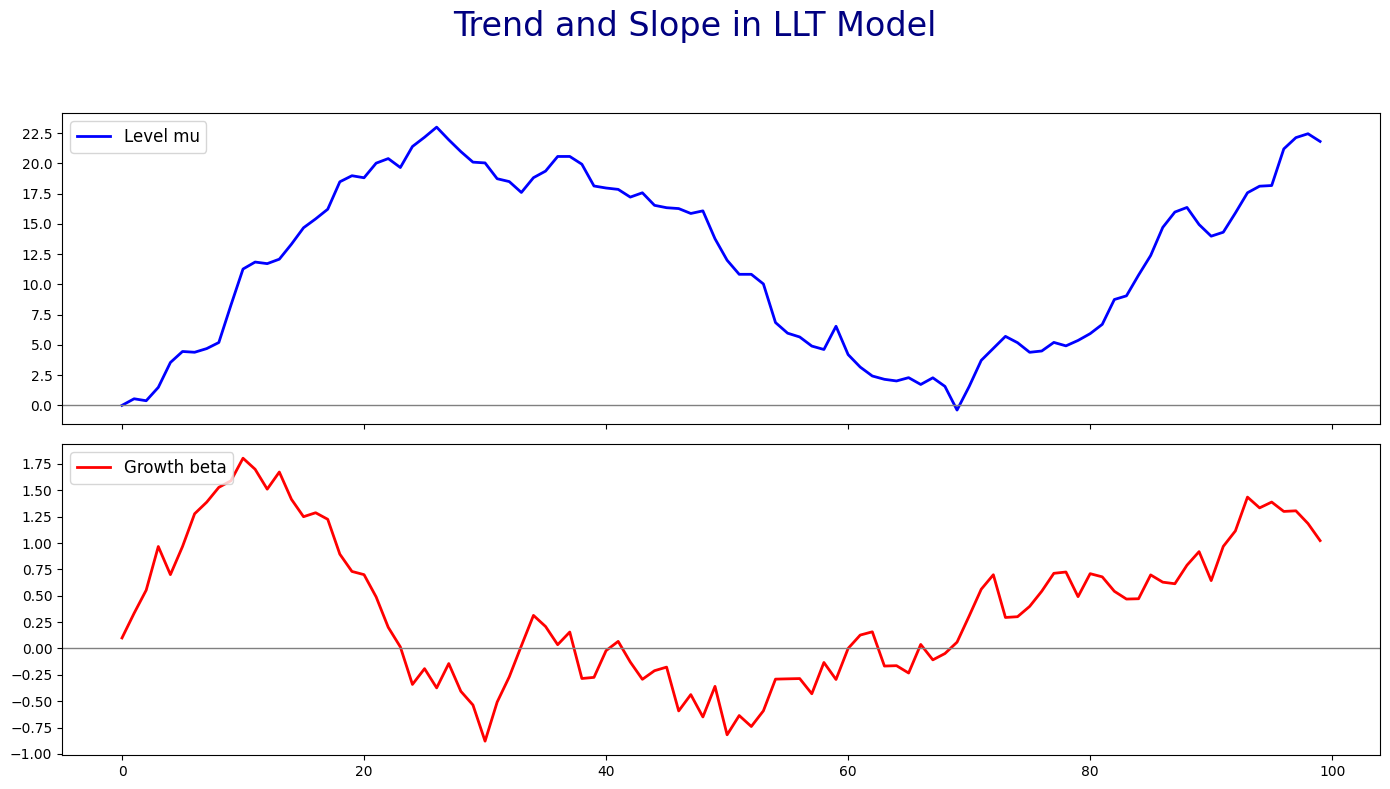

In [14]:
# Local Linear Trend Model
T = 100
sigma_eps2 = 0.1
sigma_eta2 = 1
sigma_xi2 = 0.05
mu1 = 0
beta1 = 0.1
y_llt, mu_llt, beta_llt = local_linear_trend_data_generation(T, sigma_eta2, sigma_eta2, sigma_xi2, mu1, beta1, seed=52)

# ---------------- plot ----------------
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Trend and Slope in LLT Model", fontsize=24, color="navy")

# level
axes[0].plot(mu_llt, color="blue", linewidth=2, label="Level mu")
axes[0].axhline(0, color='gray', linewidth=1)
axes[0].legend(fontsize=12, loc="upper left")
axes[0].yaxis.set_major_locator(MultipleLocator(2.5))

# slope
axes[1].plot(beta_llt, color="red", linewidth=2, label="Growth beta")
axes[1].axhline(0, color='gray', linewidth=1)
axes[1].legend(fontsize=12, loc="upper left")
axes[1].yaxis.set_major_locator(MultipleLocator(0.25))

plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

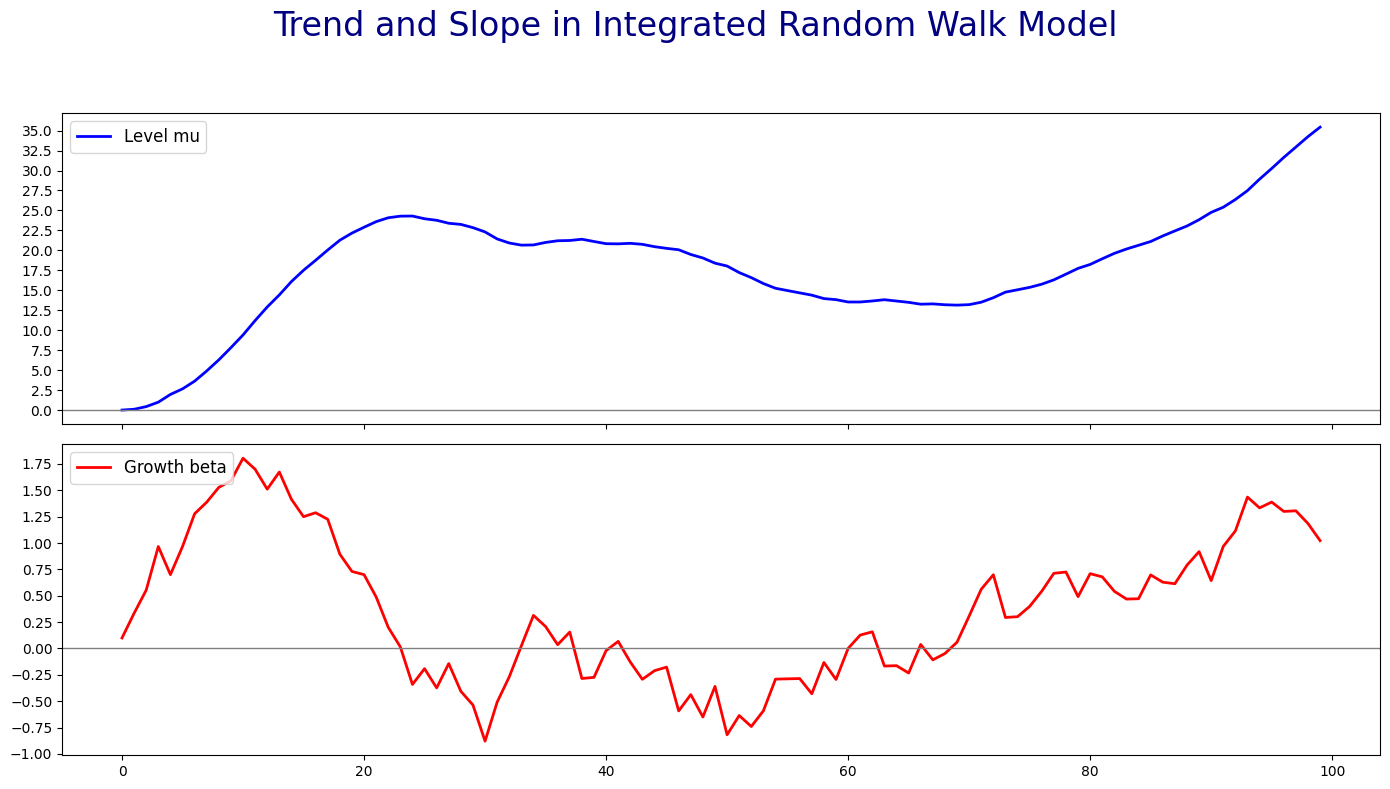

In [15]:
# Integrated Random Walk Model
T = 100
sigma_eps2 = 0.1
sigma_eta2 = 0
sigma_xi2 = 0.05
mu1 = 0
beta1 = 0.1
y_irw, mu_irw, beta_irw = local_linear_trend_data_generation(T, sigma_eta2, sigma_eta2, sigma_xi2, mu1, beta1, seed=52)

# ---------------- plot ----------------
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Trend and Slope in Integrated Random Walk Model", fontsize=24, color="navy")

# level
axes[0].plot(mu_irw, color="blue", linewidth=2, label="Level mu")
axes[0].axhline(0, color='gray', linewidth=1)
axes[0].legend(fontsize=12, loc="upper left")
axes[0].yaxis.set_major_locator(MultipleLocator(2.5))

# slope
axes[1].plot(beta_irw, color="red", linewidth=2, label="Growth beta")
axes[1].axhline(0, color='gray', linewidth=1)
axes[1].legend(fontsize=12, loc="upper left")
axes[1].yaxis.set_major_locator(MultipleLocator(0.25))

plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

### BicycleSales data

In [16]:
def kalman_filter_local_linear_trend(
    y, sigma_eps2, sigma_eta2, sigma_xi2, a1=None, P1=None
):
    """
    Local Linear Trend (LLT) Kalman filter.

    State alpha_t = [mu_t, beta_t]'
    y_t = [1 0] alpha_t + eps_t,     Var(eps_t)=sigma_eps2
    alpha_{t+1} = T alpha_t + w_t,   Var(w_t)=Q
    T = [[1,1],[0,1]]
    Q = diag(sigma_eps2, sigma_xi2)

    Inputs:
        y: array-like length T
        a1: initial state mean (2,), default [0,0]
        P1: initial state cov (2,2), default diffuse-ish
    
    Returns dict with:
        a_pred[t], P_pred[t]: prior for alpha_t (given y_{1:t-1})
        v[t], F[t], K[t]    : innovation, innovation var, Kalman gain (2,)
      a_filt[t], P_filt[t]  : filtered for alpha_t (given y_{1:t})
    """

    y = np.asarray(y, dtype=float)
    Tn= len(y)

    Tmat = np.array([[1.0, 1.0],
                     [0.0, 1.0]])
    Z = np.array([[1.0, 0.0]]) # 1*2
    H = float(sigma_eps2)
    Q = np.array([[sigma_eta2, 0.0],
                  [0.0, sigma_xi2]])
    
    # initialization
    if a1 is None:
        a1 = np.array([0.0, 0.0]) # 2*1
    else:
        a1 = np.asarray(a1, dtype=float).reshape(2)
    
    if P1 is None:
        P1 = np.diag([sigma_eps2 * 1e7, sigma_eps2 * 1e7])
    else:
        P1 = np.asarray(P1, dtype=float).reshape(2, 2)
    
    a_pred = np.zeros((Tn, 2))
    P_pred = np.zeros((Tn, 2, 2))
    a_filt = np.zeros((Tn, 2))
    P_filt = np.zeros((Tn, 2, 2))

    v = np.zeros(Tn)
    F = np.zeros(Tn)
    K = np.zeros((Tn, 2)) 

    a_pred[0] = a1
    P_pred[0] = P1

    for t in range(Tn):
        if np.isnan(y[t]):
            a_filt[t] = a_pred[t]
            P_filt[t] = P_pred[t]
            K[t] = 0.0
        
        else:
            # innovation
            v[t] = y[t] - (Z @ a_pred[t])[0]                     # scalar
            F[t] = (Z @ P_pred[t] @ Z.T)[0, 0] + H               # scalar

            # Kalman gain: (2x2)(2x1)/scalar -> (2x1)
            K_t = (P_pred[t] @ Z.T)[:, 0] / F[t]                 # (2,)
            K[t] = K_t

            # update
            a_filt[t] = a_pred[t] + K_t * v[t]                   # (2,)
            P_filt[t] = P_pred[t] - np.outer(K_t, (Z @ P_pred[t])[0])  # 2x2

        # predict next
        if t < Tn - 1:
            a_pred[t + 1] = Tmat @ a_filt[t]
            P_pred[t + 1] = Tmat @ P_filt[t] @ Tmat.T + Q

    return {
        "a_pred": a_pred, "P_pred": P_pred,
        "v": v, "F": F, "K": K,
        "a_filt": a_filt, "P_filt": P_filt,
        "mu_filt": a_filt[:, 0],
        "beta_filt": a_filt[:, 1],
        "mu_pred": a_pred[:, 0],
        "beta_pred": a_pred[:, 1],
    }



def local_linear_trend_forecast(
    a_TT, P_TT,
    sigma_eps2, sigma_eta2, sigma_xi2,
    h=5, alpha=0.05
):
    """
    a_TT : [mu_TT, beta_TT]
    P_TT : 2x2 covariance matrix of filtered state

    Returns:
        mean[h], lower[h], upper[h], var_y[h]
    """

    mu_TT, beta_TT = a_TT

    # system matrices
    Tmat = np.array([[1., 1.],
                     [0., 1.]])
    Q = np.array([[sigma_eta2, 0.],
                  [0., sigma_xi2]])
    Z = np.array([[1., 0.]])

    z = norm.ppf(1 - alpha/2)

    mean = np.zeros(h)
    var_y = np.zeros(h)

    a = a_TT.copy()
    P = P_TT.copy()

    for i in range(h):
        # predict next state
        a = Tmat @ a
        P = Tmat @ P @ Tmat.T + Q

        mean[i] = a[0]  # mu part
        var_y[i] = (Z @ P @ Z.T)[0, 0] + sigma_eps2

    se = np.sqrt(var_y)
    lower = mean - z * se
    upper = mean + z * se

    return mean, lower, upper, var_y


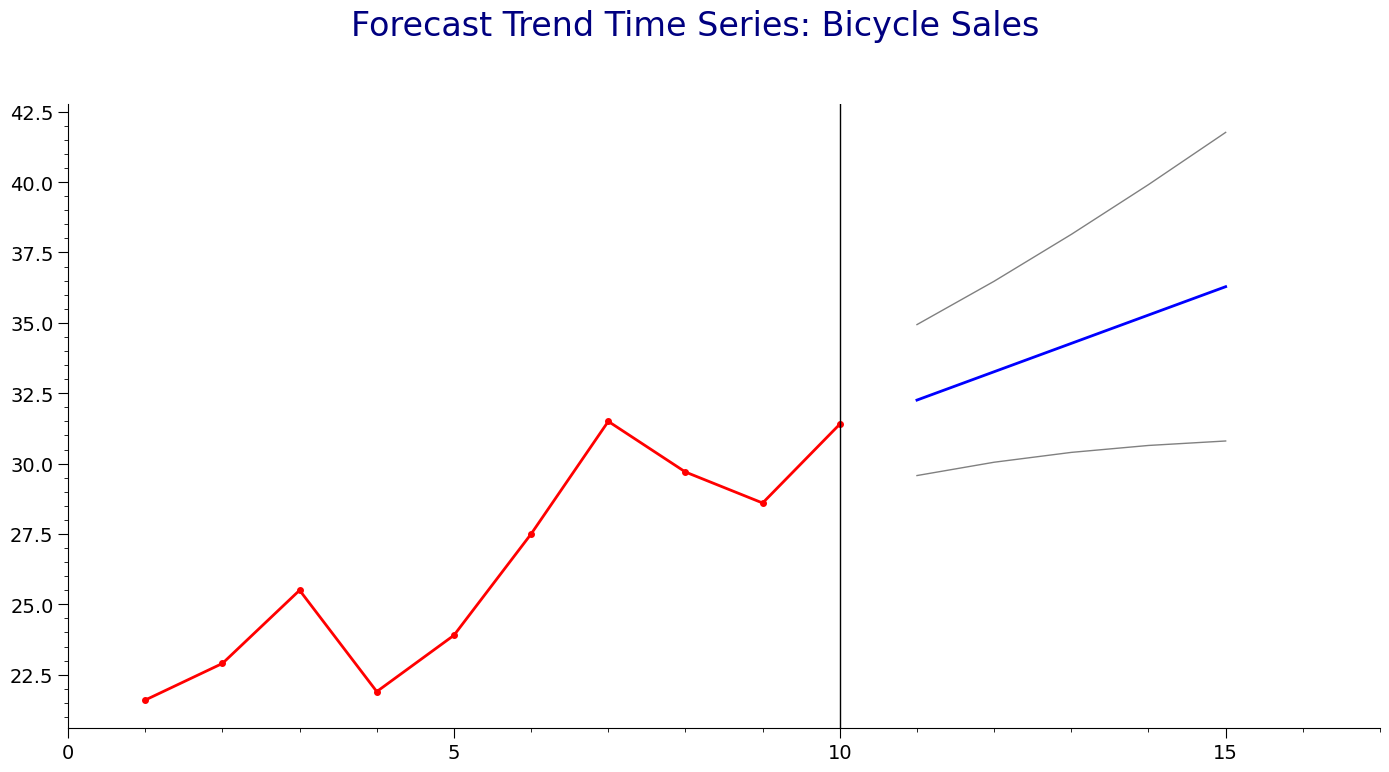

In [17]:
df = pd.read_excel("BicycleSales.xlsx")
y_bs = df.iloc[:, 1]
sigma_eps2=3.5
sigma_eta2=0.4
sigma_xi2=0.15

res2 = kalman_filter_local_linear_trend(
    y_bs,
    sigma_eps2,
    sigma_eta2,
    sigma_xi2
)

a_TT_bs = res2["a_filt"][-1]
P_TT_bs = res2["P_filt"][-1]

f_mean_bs, f_low_bs, f_up_bs, f_var_bs = local_linear_trend_forecast(
    a_TT_bs, P_TT_bs,
    sigma_eps2, sigma_eta2, sigma_xi2,
    h=5,
    alpha=0.32
)

# plot
T = len(y_bs)
x_data = np.arange(1, T + 1)
x_fcst = np.arange(T + 1, T + h + 1)

fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Forecast Trend Time Series: Bicycle Sales", fontsize=24, color="navy", y=0.96)

ax.plot(x_data, y_bs, "-o", color="red", markersize=4, linewidth=2)
ax.axvline(T, color="black", linewidth=1)
# forecast mean
ax.plot(x_fcst, f_mean_bs, color='blue', linewidth=2)
# CI bounds
ax.plot(x_fcst, f_up_bs, color='grey', linewidth=1)
ax.plot(x_fcst, f_low_bs, color='grey', linewidth=1)

ax.set_xlim(0, T + h + 2)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.yaxis.set_major_locator(MultipleLocator(2.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.5))

ax.tick_params(axis='both', which='major', labelsize=14, length=7)
ax.tick_params(axis='both', which='minor', length=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### Missing Observations

In [18]:
df = pd.read_excel("GasolineSales2missing.xlsx")
y_gs_missing_raw = df.iloc[:, 1]
y_gs_missing = pd.to_numeric(y_gs_missing_raw.replace({".": np.nan})).to_numpy()
y_gs_missing

/var/folders/gr/k1dgsfnd1sb2lct0qjkjj99c0000gn/T/ipykernel_80783/3962647942.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_gs_missing = pd.to_numeric(y_gs_missing_raw.replace({".": np.nan})).to_numpy()


array([17., 21., 19., 23., 18., 16., 20., 18., 22., nan, nan, nan, nan,
       nan, nan, 33., 28., 32., 30., 29., 34., 33.])

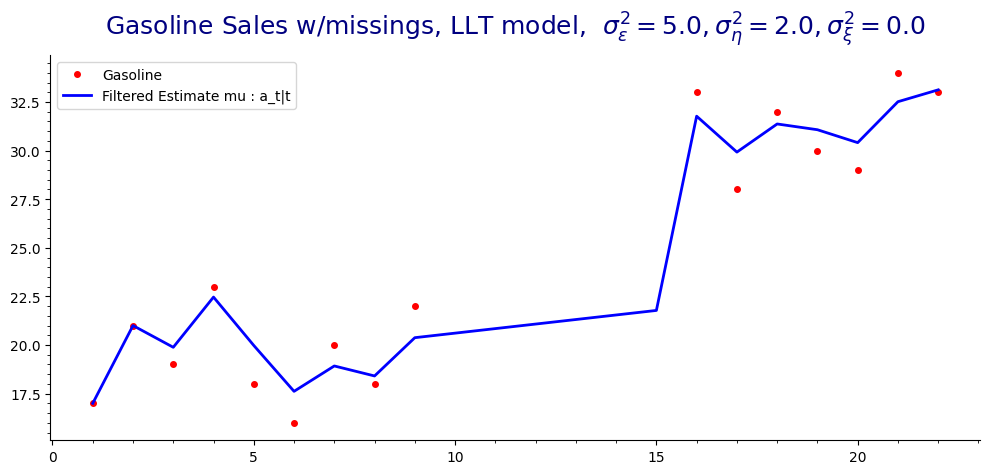

In [19]:
sigma_eps2 = 5.0
sigma_eta2 = 2.0
sigma_xi2 = 0.0

res3 = kalman_filter_local_linear_trend(
    y_gs_missing,
    sigma_eps2,
    sigma_eta2,
    sigma_xi2
)

f_mu_missing = res3["mu_filt"]

x = np.arange(1, len(y) + 1)
obs_mask = ~np.isnan(y)

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title(rf"Gasoline Sales w/missings, LLT model,  $\sigma_\varepsilon^2={sigma_eps2}, \sigma_\eta^2={sigma_eta2}, \sigma_\xi^2={sigma_xi2}$",
             fontsize=18, color="navy", pad=15)

ax.plot(x[obs_mask], y_gs_missing[obs_mask], 'o', color='red', markersize=4, label="Gasoline")
ax.plot(x, f_mu_missing, '-', color='blue', linewidth=2, label="Filtered Estimate mu : a_t|t")

ax.legend(loc="upper left")
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.yaxis.set_major_locator(MultipleLocator(2.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

# Question (b)(c)

In [20]:
variances = {

    "Gasoline1": {
        "LL":  {"eps": 5.7, "eta": 1.5},
        "LLT": {"eps": 6.1, "eta": 1.7, "zeta": 0.25},
    },

    "Gasoline2": {
        "LL":  {"eps": 3.5, "eta": 10.0},
        "LLT": {"eps": 3.0, "eta": 10.0, "zeta": 0.2},
    },

    "Bicycle": {
        "LL":  {"eps": 0.9, "eta": 5.7},
        "LLT": {"eps": 3.5, "eta": 0.4, "zeta": 0.15},
    },

    "Var1": {
        "LL":  {"eps": 3.0, "eta": 2.4},
        "LLT": {"eps": 3.5, "eta": 0.9, "zeta": 0.2},
    },

    "Var2": {
        "LL":  {"eps": 0.7, "eta": 4.0},
        "LLT": {"eps": 1.5, "eta": 2.0, "zeta": 0.05},
    },

    "Var3": {
        "LL":  {"eps": 2.0, "eta": 2.35},
        "LLT": {"eps": 2.0, "eta": 0.3, "zeta": 1.0},
    },

    "Var4": {
        "LL":  {"eps": 1.2, "eta": 1.5},
        "LLT": {"eps": 1.2, "eta": 1.4, "zeta": 0.01},
    },

    "Var5": {
        "LL":  {"eps": 1.4, "eta": 1.3},
        "LLT": {"eps": 1.5, "eta": 1.0, "zeta": 0.02},
    },

    "Var6": {
        "LL":  {"eps": 1.3, "eta": 2.3},
        "LLT": {"eps": 1.0, "eta": 2.7, "zeta": 0.06},
    },

    "Var7": {
        "LL":  {"eps": 1.9, "eta": 1.2},
        "LLT": {"eps": 2.2, "eta": 0.1, "zeta": 0.1},
    },

    "Var8": {
        "LL":  {"eps": 0.5, "eta": 4.0},
        "LLT": {"eps": 0.7, "eta": 3.5, "zeta": 0.05},
    },

    "Var9": {
        "LL":  {"eps": 0.8, "eta": 3.5},
        "LLT": {"eps": 1.0, "eta": 2.5, "zeta": 0.1},
    }
}


### GasolineSales1

In [21]:
y_gs1 = pd.read_excel("GasolineSales1.xlsx").iloc[:, 1]
T = len(y_gs1)
T1 = T // 2

# running average
f_gs1_ra = helper.running_average_forecast(y_gs1)
# random walk
f_gs1_rw = helper.lag_forecast(y_gs1)

# exponential smoothing
_, f_gs1_es, _ = helper.estimate_alpha_exponential_smoothing(y_gs1)

# running trend
f_gs1_rt, _, _ = helper.running_trend_forecast(y_gs1)

# random walk with drift
_, f_gs1_rwd, _ = helper.random_walk_plus_drift_forecast(y_gs1)

# holt-winters
_, _, f_gs1_hw, _, _ = helper.estimate_alpha_beta_holt_winters(y_gs1)

# Local level
sigma_eps2 = variances["Gasoline1"]["LL"]["eps"] 
sigma_eta2 = variances["Gasoline1"]["LL"]["eta"]
f_gs1_ll = kalman_filter_local_level(y_gs1, sigma_eps2, sigma_eta2)["a_filt"]
# Local linear trend
sigma_eps2 = variances["Gasoline1"]["LLT"]["eps"] 
sigma_eta2 = variances["Gasoline1"]["LLT"]["eta"]
sigma_xi2 = variances["Gasoline1"]["LLT"]["zeta"]
f_gs1_llt = kalman_filter_local_linear_trend(y_gs1, sigma_eps2, sigma_eta2, sigma_xi2)["mu_filt"]

forecasts = {
    "Running Average": f_gs1_ra,
    "Random Walk": f_gs1_rw,
    "Exp Smo.": f_gs1_es,
    "Running Trend": f_gs1_rt,
    "Random Walk with Drift": f_gs1_rwd,
    "Holt-Winters": f_gs1_hw,
    "Local Level": f_gs1_ll,
    "Local Linear Trend": f_gs1_llt,
}

In [22]:
def metrics(y_true, y_hat):

    y_true = np.asarray(y_true, dtype=float)
    y_hat = np.asarray(y_hat, dtype=float)

    mask = ~np.isnan(y_true) & ~np.isnan(y_hat)
    y_true = y_true[mask]
    y_hat = y_hat[mask]

    u = y_true - y_hat

    me = float(np.mean(u))
    mae = float(np.mean(np.abs(u)))

    nonzero = np.abs(y_true) > 1e-12
    mape = float(np.mean(100.0 * np.abs(u[nonzero]) / np.abs(y_true[nonzero])))

    mse = float(np.mean(u**2))
    return me, mae, mape, mse


y_eval = np.asarray(y_gs1[T1:], dtype=float)

rows = []
for name, f in forecasts.items():
    f_eval = np.asarray(f[T1:], dtype=float)
    rows.append((name, metrics(y_eval, f_eval)))


title = f"FORECAST COMPARISONS, {len(y_eval)} FORECASTS"
line_eq = "=" * 66
line_dash = "-" * 66

print(title)
print(line_eq)
print(f"{'Method':<24}{'ME':>10}{'MAE':>10}{'MAPE':>10}{'MSE':>10}")
print(line_dash)

for name, (me, mae, mape, mse) in rows:
    print(f"{name:<24}{me:>10.2f}{mae:>10.2f}{mape:>10.2f}{mse:>10.2f}")

print(line_eq)

FORECAST COMPARISONS, 6 FORECASTS
Method                          ME       MAE      MAPE       MSE
------------------------------------------------------------------
Running Average               0.35      2.20     11.88      6.69
Random Walk                   1.00      4.00     20.74     19.00
Exp Smo.                      0.67      2.44     12.99      8.24
Running Trend                 0.61      2.56     13.72      9.47
Random Walk with Drift        0.80      4.29     22.30     20.99
Holt-Winters                  1.52      4.76     24.79     27.74
Local Level                   0.35      1.53      8.18      3.43
Local Linear Trend            0.32      1.35      7.17      2.52


#### MZ test

In [23]:
def mz_test(y, yhat):

    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)

    X = sm.add_constant(yhat)
    model = sm.OLS(y, X).fit()

    ftest = model.f_test("const = 0, x1 = 1")

    return model, float(ftest.fvalue), float(ftest.pvalue)

In [24]:
y_eval = np.asarray(y_gs1[T1:], dtype=float)

print("\nMZ TEST RESULTS")
print("=" * 60)
print(f"{'Method':<25}{'F-stat':>12}{'p-value':>12}")
print("-" * 60)

for name, f in forecasts.items():

    f_eval = np.asarray(f[T1:], dtype=float)

    _, Fval, pval = mz_test(y_eval, f_eval)

    print(f"{name:<25}{Fval:>12.3f}{pval:>12.4f}")

print("=" * 60)



MZ TEST RESULTS
Method                         F-stat     p-value
------------------------------------------------------------
Running Average                 3.483      0.1330
Random Walk                     6.817      0.0515
Exp Smo.                        3.267      0.1442
Running Trend                   4.099      0.1075
Random Walk with Drift          7.670      0.0428
Holt-Winters                    9.477      0.0304
Local Level                     3.321      0.1413
Local Linear Trend              2.161      0.2311


#### DM test

In [25]:
def dm_test(e1, e2):
    d = e1**2 - e2**2
    d = d[~np.isnan(d)]

    mean_d = np.mean(d)
    se = np.std(d, ddof=1) / np.sqrt(len(d))

    stat = mean_d / se
    p = 2 * (1 - t.cdf(abs(stat), df=len(d)-1))
    return stat, p

In [26]:
errors = {}

for name, f in forecasts.items():
    f_eval = np.asarray(f[T1:], dtype=float)
    errors[name] = y_eval - f_eval

benchmark = "Local Level"

print("DM TEST RESULTS")
print("=" * 60)
print(f"Benchmark = {benchmark}")
print("-" * 60)
print(f"{'Compare to':<25}{'t-stat':>12}{'p-value':>12}")
print("-" * 60)

for name in forecasts.keys():
    if name == benchmark:
        continue

    stat, p = dm_test(errors[name], errors[benchmark])

    print(f"{name:<25}{stat:>12.3f}{p:>12.4f}")

print("=" * 60)

DM TEST RESULTS
Benchmark = Local Level
------------------------------------------------------------
Compare to                     t-stat     p-value
------------------------------------------------------------
Running Average                 2.007      0.1010
Random Walk                     2.631      0.0465
Exp Smo.                        2.427      0.0596
Running Trend                   2.390      0.0624
Random Walk with Drift          2.886      0.0343
Holt-Winters                    3.114      0.0264
Local Linear Trend             -1.854      0.1230


### GasolineSales2

In [27]:
y_gs2 = pd.read_excel("GasolineSales2.xlsx").iloc[:, 1].to_numpy(dtype=float)

T  = len(y_gs2)
T1 = T // 2

y_eval = y_gs2[T1:] 

# ========= forecasts =========

# running average
f_gs2_ra = helper.running_average_forecast(y_gs2)

# random walk
f_gs2_rw = helper.lag_forecast(y_gs2)

# exponential smoothing
_, f_gs2_es, _ = helper.estimate_alpha_exponential_smoothing(y_gs2)

# running trend
f_gs2_rt, _, _ = helper.running_trend_forecast(y_gs2)

# random walk with drift
_, f_gs2_rwd, _ = helper.random_walk_plus_drift_forecast(y_gs2)

# holt-winters
_, _, f_gs2_hw, _, _ = helper.estimate_alpha_beta_holt_winters(y_gs2)

# Local level (variances provided)
par_ll = variances["Gasoline2"]["LL"]
f_gs2_ll = kalman_filter_local_level(y_gs2, par_ll["eps"], par_ll["eta"])["a_filt"]

# Local linear trend (variances provided)
par_llt = variances["Gasoline2"]["LLT"]
f_gs2_llt = kalman_filter_local_linear_trend(
    y_gs2, par_llt["eps"], par_llt["eta"], par_llt["zeta"]
)["mu_filt"]


forecasts = {
    "Running Average": f_gs2_ra,
    "Random Walk": f_gs2_rw,
    "Exp Smo.": f_gs2_es,
    "Running Trend": f_gs2_rt,
    "Random Walk with Drift": f_gs2_rwd,
    "Holt-Winters": f_gs2_hw,
    "Local Level": f_gs2_ll,
    "Local Linear Trend": f_gs2_llt,
}

In [28]:
# ========= error metrics =========
rows = []
for name, f in forecasts.items():
    f_eval = np.asarray(f[T1:], dtype=float)
    rows.append((name, metrics(y_eval, f_eval)))

title = f"FORECAST COMPARISONS (Gasoline2), {len(y_eval)} FORECASTS"
line_eq = "=" * 66
line_dash = "-" * 66

print(title)
print(line_eq)
print(f"{'Method':<24}{'ME':>10}{'MAE':>10}{'MAPE':>10}{'MSE':>10}")
print(line_dash)

for name, (me, mae, mape, mse) in rows:
    print(f"{name:<24}{me:>10.2f}{mae:>10.2f}{mape:>10.2f}{mse:>10.2f}")

print(line_eq)

# ========= MZ test =========
print("\nMZ TEST RESULTS (Gasoline2)")
print("=" * 60)
print(f"{'Method':<25}{'F-stat':>12}{'p-value':>12}")
print("-" * 60)

for name, f in forecasts.items():
    f_eval = np.asarray(f[T1:], dtype=float)
    _, Fval, pval = mz_test(y_eval, f_eval)
    print(f"{name:<25}{Fval:>12.3f}{pval:>12.4f}")

print("=" * 60)

# ========= DM test =========
errors = {}
for name, f in forecasts.items():
    f_eval = np.asarray(f[T1:], dtype=float)
    errors[name] = y_eval - f_eval

benchmark = "Local Level"

print("\nDM TEST RESULTS (Gasoline2)")
print("=" * 60)
print(f"Benchmark = {benchmark}")
print("-" * 60)
print(f"{'Compare to':<25}{'t-stat':>12}{'p-value':>12}")
print("-" * 60)

for name in forecasts.keys():
    if name == benchmark:
        continue
    stat, p = dm_test(errors[name], errors[benchmark])
    print(f"{name:<25}{stat:>12.3f}{p:>12.4f}")

print("=" * 60)


FORECAST COMPARISONS (Gasoline2), 11 FORECASTS
Method                          ME       MAE      MAPE       MSE
------------------------------------------------------------------
Running Average               8.63      8.63     27.49     83.91
Random Walk                   1.64      3.82     13.06     20.36
Exp Smo.                      2.42      4.36     14.18     33.12
Running Trend                 2.67      4.22     13.79     30.44
Random Walk with Drift        0.86      3.92     13.51     20.85
Holt-Winters                  0.65      4.19     14.47     26.80
Local Level                   0.42      0.78      2.64      0.97
Local Linear Trend            0.14      0.65      2.22      0.62

MZ TEST RESULTS (Gasoline2)
Method                         F-stat     p-value
------------------------------------------------------------
Running Average                36.560      0.0000
Random Walk                     9.718      0.0056
Exp Smo.                       10.954      0.0039
Running Tre

### BicycleSales

In [29]:
y_bs = pd.read_excel("BicycleSales.xlsx").iloc[:, 1].to_numpy(dtype=float)

T  = len(y_bs)
T1 = T // 2
y_eval = y_bs[T1:]


# ========= forecasts =========

# running average
f_bs_ra = helper.running_average_forecast(y_bs)

# random walk
f_bs_rw = helper.lag_forecast(y_bs)

# exponential smoothing
_, f_bs_es, _ = helper.estimate_alpha_exponential_smoothing(y_bs)

# running trend
f_bs_rt, _, _ = helper.running_trend_forecast(y_bs)

# random walk with drift
_, f_bs_rwd, _ = helper.random_walk_plus_drift_forecast(y_bs)

# holt-winters
_, _, f_bs_hw, _, _ = helper.estimate_alpha_beta_holt_winters(y_bs)

# Local level (variances provided)
par_ll = variances["Bicycle"]["LL"]
f_bs_ll = kalman_filter_local_level(y_bs, par_ll["eps"], par_ll["eta"])["a_filt"]

# Local linear trend (variances provided)
par_llt = variances["Bicycle"]["LLT"]
f_bs_llt = kalman_filter_local_linear_trend(
    y_bs, par_llt["eps"], par_llt["eta"], par_llt["zeta"]
)["mu_filt"]

forecasts = {
    "Running Average": f_bs_ra,
    "Random Walk": f_bs_rw,
    "Exp Smo.": f_bs_es,
    "Running Trend": f_bs_rt,
    "Random Walk with Drift": f_bs_rwd,
    "Holt-Winters": f_bs_hw,
    "Local Level": f_bs_ll,
    "Local Linear Trend": f_bs_llt,
}


# ========= error metrics =========
rows = []
for name, f in forecasts.items():
    f_eval = np.asarray(f[T1:], dtype=float)
    rows.append((name, metrics(y_eval, f_eval)))

title = f"FORECAST COMPARISONS (Bicycle), {len(y_eval)} FORECASTS"
line_eq = "=" * 66
line_dash = "-" * 66

print(title)
print(line_eq)
print(f"{'Method':<24}{'ME':>10}{'MAE':>10}{'MAPE':>10}{'MSE':>10}")
print(line_dash)

for name, (me, mae, mape, mse) in rows:
    print(f"{name:<24}{me:>10.2f}{mae:>10.2f}{mape:>10.2f}{mse:>10.2f}")

print(line_eq)


# ========= MZ test =========
print("\nMZ TEST RESULTS (Bicycle)")
print("=" * 60)
print(f"{'Method':<25}{'F-stat':>12}{'p-value':>12}")
print("-" * 60)

for name, f in forecasts.items():
    f_eval = np.asarray(f[T1:], dtype=float)
    _, Fval, pval = mz_test(y_eval, f_eval)
    print(f"{name:<25}{Fval:>12.3f}{pval:>12.4f}")

print("=" * 60)


# ========= DM test =========
errors = {}
for name, f in forecasts.items():
    f_eval = np.asarray(f[T1:], dtype=float)
    errors[name] = y_eval - f_eval

benchmark = "Local Level"

print("\nDM TEST RESULTS (Bicycle)")
print("=" * 60)
print(f"Benchmark = {benchmark}")
print("-" * 60)
print(f"{'Compare to':<25}{'t-stat':>12}{'p-value':>12}")
print("-" * 60)

for name in forecasts.keys():
    if name == benchmark:
        continue
    stat, p = dm_test(errors[name], errors[benchmark])
    print(f"{name:<25}{stat:>12.3f}{p:>12.4f}")

print("=" * 60)

FORECAST COMPARISONS (Bicycle), 5 FORECASTS
Method                          ME       MAE      MAPE       MSE
------------------------------------------------------------------
Running Average               5.04      5.04     16.80     27.74
Random Walk                   1.50      2.66      8.92      8.25
Exp Smo.                      2.04      3.20     10.70     13.33
Running Trend                 0.93      2.26      7.69      8.16
Random Walk with Drift        0.41      2.70      9.12      7.56
Holt-Winters                 -0.14      1.92      6.50      4.85
Local Level                   0.20      0.33      1.10      0.13
Local Linear Trend            0.27      1.15      3.89      1.74

MZ TEST RESULTS (Bicycle)
Method                         F-stat     p-value
------------------------------------------------------------
Running Average                18.386      0.0207
Random Walk                     4.362      0.1295
Exp Smo.                        7.169      0.0720
Running Trend   

### DataAssignment1

In [30]:
df = pd.read_excel("DataAssignment1.xlsx")

for var in df.columns:

    print("\n")
    print("############################################################")
    print(f"### RESULTS FOR: {var}")
    print("############################################################")

    y = df[var].to_numpy(dtype=float)

    T = len(y)
    T1 = T // 2
    y_eval = y[T1:]

    # ========= Forecasts =========

    f_ra = helper.running_average_forecast(y)
    f_rw = helper.lag_forecast(y)

    # # Exp smoothing
    # alpha_path, _, _ = helper.estimate_alpha_exponential_smoothing(y[:T1])
    # alpha_hat = float(np.asarray(alpha_path)[-1])
    # f_es = helper.exp_smoothing_forecast(y, alpha_hat)

    # Exp smoothing
    _, f_es, _ = helper.estimate_alpha_exponential_smoothing(y)

    # Running trend
    f_rt, _, _ = helper.running_trend_forecast(y)

    # # RW + drift
    # _, _, c_path = helper.random_walk_plus_drift_forecast(y[:T1])
    # c_hat = float(np.asarray(c_path)[-1])
    # f_rwd = np.asarray(helper.lag_forecast(y), dtype=float) + c_hat

    # RW + drift
    _, f_rwd, _ = helper.random_walk_plus_drift_forecast(y)

    # # Holt–Winters
    # alpha_path_hw, beta_path_hw, _, _, _ = helper.estimate_alpha_beta_holt_winters(y[:T1])
    # alpha_hat_hw = float(np.asarray(alpha_path_hw)[-1])
    # beta_hat_hw  = float(np.asarray(beta_path_hw)[-1])
    # f_hw = helper.holt_fitted_forecast_series(y, alpha_hat_hw, beta_hat_hw)

    # Holt–Winters
    _, _, f_hw, _, _ = helper.estimate_alpha_beta_holt_winters(y)

    # Local Level
    par_ll = variances[var]["LL"]
    f_ll = kalman_filter_local_level(y, par_ll["eps"], par_ll["eta"])["a_filt"]

    # Local Linear Trend
    par_llt = variances[var]["LLT"]
    f_llt = kalman_filter_local_linear_trend(
        y, par_llt["eps"], par_llt["eta"], par_llt["zeta"]
    )["mu_filt"]

    forecasts = {
        "Running Average": f_ra,
        "Random Walk": f_rw,
        "Exp Smo.": f_es,
        "Running Trend": f_rt,
        "Random Walk with Drift": f_rwd,
        "Holt-Winters": f_hw,
        "Local Level": f_ll,
        "Local Linear Trend": f_llt,
    }


    # ============================================================
    # Error metrics
    # ============================================================
    print("\nFORECAST METRICS")
    print("=" * 66)
    print(f"{'Method':<24}{'ME':>10}{'MAE':>10}{'MAPE':>10}{'MSE':>10}")
    print("-" * 66)

    for name, f in forecasts.items():
        f_eval = np.asarray(f[T1:], dtype=float)
        me, mae, mape, mse = metrics(y_eval, f_eval)
        print(f"{name:<24}{me:>10.2f}{mae:>10.2f}{mape:>10.2f}{mse:>10.2f}")

    print("=" * 66)


    # ============================================================
    # MZ TEST
    # ============================================================
    print("\nMZ TEST RESULTS")
    print("=" * 60)
    print(f"{'Method':<25}{'F-stat':>12}{'p-value':>12}")
    print("-" * 60)

    for name, f in forecasts.items():
        f_eval = np.asarray(f[T1:], dtype=float)
        _, Fval, pval = mz_test(y_eval, f_eval)
        print(f"{name:<25}{Fval:>12.3f}{pval:>12.4f}")

    print("=" * 60)


    # ============================================================
    # DM TEST
    # ============================================================
    errors = {}
    for name, f in forecasts.items():
        f_eval = np.asarray(f[T1:], dtype=float)
        errors[name] = y_eval - f_eval

    benchmark = "Local Level"

    print("\nDM TEST RESULTS")
    print("=" * 60)
    print(f"Benchmark = {benchmark}")
    print("-" * 60)
    print(f"{'Compare to':<25}{'t-stat':>12}{'p-value':>12}")
    print("-" * 60)

    for name in forecasts.keys():
        if name == benchmark:
            continue
        stat, p = dm_test(errors[name], errors[benchmark])
        print(f"{name:<25}{stat:>12.3f}{p:>12.4f}")

    print("=" * 60)




############################################################
### RESULTS FOR: Var1
############################################################

FORECAST METRICS
Method                          ME       MAE      MAPE       MSE
------------------------------------------------------------------
Running Average               0.47      3.60      7.95     21.65
Random Walk                  -0.08      2.13      4.69     11.93
Exp Smo.                     -0.36      2.09      4.57     12.23
Running Trend                -1.73      3.98      9.20     23.80
Random Walk with Drift       -0.08      2.19      4.83     12.38
Holt-Winters                 -0.72      2.39      5.24     14.14
Local Level                  -0.05      0.75      1.65      1.78
Local Linear Trend            0.04      0.90      1.97      2.01

MZ TEST RESULTS
Method                         F-stat     p-value
------------------------------------------------------------
Running Average                 5.448      0.0116
Random

# Question (e)

In [31]:
def running_average_forecast_h(y, h=1):
    y = np.asarray(y, dtype=float)
    T = len(y)
    f = np.full(T, np.nan, dtype=float)

    csum = np.cumsum(y)

    for j in range(h, T):
        t = j - h
        f[j] = csum[t] / (t+1)

    return f


def random_walk_forecast_h(y, h=1):
    y = np.asarray(y, dtype=float)
    T = len(y)
    f = np.full(T, np.nan, dtype=float)

    f[h:] = y[:-h]
    return f


def rwd_forecast_h(y, h=1):
    y = np.asarray(y, dtype=float)
    T = len(y)
    f = np.full(T, np.nan, dtype=float)

    for j in range(h, T):
        t = j - h

        dy = np.diff(y[:t+1])
        c_hat = np.mean(dy) if len(dy) > 0 else 0.0

        f[j] = y[t] + h * c_hat
    return f


def running_trend_forecast_h(y, h=1):
    y = np.asarray(y, dtype=float)
    T = len(y)
    f = np.full(T, np.nan, dtype=float)

    for j in range(h, T):
        t = j - h
        
        x = np.arange(1, t + 2, dtype=float)
        yt = y[:t+1]

        xbar = x.mean()
        ybar = yt.mean()

        denom = np.sum((x - xbar)**2)
        if denom == 0.0:
            a = ybar
            b = 0.0
        else: 
            nom = np.sum((x - xbar)* yt)
            b = nom / denom
            a = ybar - b * xbar
        
        f[j] = a + b * (j+1)
    return f


def _ses_sse_and_last_level(y, alpha):
    "Given y[0..t], compute 1-step-ahead SSE and return last level l_t under SES."
    n = len(y)
    l = y[0]
    sse = 0.0

    for k in range(1, n):
        yhat = l
        err = y[k] - yhat
        sse += err * err
        l = alpha * y[k] + (1 - alpha) * l
    return sse, l


def exp_smoothing_forecast_h_rolling(y, h=1, alpha_grid=None):
    y = np.asarray(y, dtype=float)
    T = len(y)
    f = np.full(T, np.nan, dtype=float)
    
    if alpha_grid is None:
        alpha_grid = np.linspace(0.01, 0.99, 99)
    
    for t in range(0, T- h):
        y_sub = y[:t+1]
        if len(y_sub) < 2:
            l_t = y_sub[0]
        else:
            best_sse = np.inf
            best_l = None
            for a in alpha_grid:
                sse, l = _ses_sse_and_last_level(y_sub, a)
                if sse < best_sse:
                    best_sse = sse
                    best_l = l
            l_t = best_l

        f[t + h] = l_t
    return f


def _holt_sse_and_last_states(y, alpha, beta):
    """
    Given y[0..t], compute 1-step-ahead SSE and return last (l_t, g_t) under Holt.
    """
    n = len(y)
    l = y[0]
    g = (y[1] - y[0]) if n>=2 else 0.0
    sse = 0.0

    for k in range(1, n):
        yhat = l + g
        err = y[k] - yhat
        sse += err * err

        l_new = alpha * y[k] + (1 - alpha) * (l + g)
        g_new = beta * (l_new - l) + (1 - beta) * g

        l, g = l_new, g_new

    return sse, l, g


def holt_forecast_h_rolling(y, h=1, alpha_grid=None, beta_grid=None):
    y = np.asarray(y, dtype=float)
    T = len(y)
    f = np.full(T, np.nan, dtype=float)

    if alpha_grid is None:
        alpha_grid = np.linspace(0.01, 0.99, 99)
    if beta_grid is None:
        beta_grid = np.linspace(0.01, 0.99, 99)

    for t in range(0, T - h):
        y_sub = y[:t+1]

        if len(y_sub) < 2:
            l_t, g_t = y_sub[0], 0.0
        else:
            best_sse = np.inf
            best_l, best_g = None, None
            for a in alpha_grid:
                for b in beta_grid:
                    sse, l, gt = _holt_sse_and_last_states(y_sub, a, b)
                    if sse < best_sse:
                        best_sse = sse
                        best_l, best_g = l, gt
            l_t, g_t = best_l, best_g

        f[t + h] = l_t + h * g_t
    return f

In [32]:
def ar1_forecast_h_rolling_ols(y, h=1, min_train=5):
    y = np.asarray(y, dtype=float)
    T = len(y)
    f = np.full(T, np.nan, dtype=float)

    for t in range(0, T - h):
        if (t + 1) < min_train:
            continue
        if t < 1:
            continue  # need at least y0,y1

        y_sub = y[:t+1]
        Y = y_sub[1:]
        X = np.column_stack([np.ones(t), y_sub[:-1]])  # [1, y_{s-1}]

        # OLS
        beta = np.linalg.lstsq(X, Y, rcond=None)[0]
        c_hat, phi_hat = float(beta[0]), float(beta[1])

        # h-step forecast via recursion
        yhat = y_sub[-1]
        for _ in range(h):
            yhat = c_hat + phi_hat * yhat

        f[t + h] = yhat

    return f


def _ma1_sse_and_last_innov(y, mu, theta):
    """
    Returns SSE over k=1..n-1 and last innovation e_{n-1}
    """
    n = len(y)
    e_prev = 0.0
    sse = 0.0

    for k in range(1, n):
        yhat = mu + theta * e_prev
        e = y[k] - yhat
        sse += e * e
        e_prev = e

    return sse, e_prev


def ma1_forecast_h_rolling(y, h=1, theta_grid=None, min_train=5):
    y = np.asarray(y, dtype=float)
    T = len(y)
    f = np.full(T, np.nan, dtype=float)

    if theta_grid is None:
        theta_grid = np.linspace(-0.99, 0.99, 199)

    for t in range(0, T - h):
        if (t + 1) < min_train:
            continue

        y_sub = y[:t+1]
        mu = float(np.mean(y_sub))

        if len(y_sub) < 2:
            f[t + h] = mu
            continue

        best_sse = np.inf
        best_theta = 0.0
        best_e_t = 0.0

        for th in theta_grid:
            sse, e_t = _ma1_sse_and_last_innov(y_sub, mu, th)
            if sse < best_sse:
                best_sse = sse
                best_theta = th
                best_e_t = e_t

        # h-step forecast
        if h == 1:
            f[t + 1] = mu + best_theta * best_e_t
        else:
            f[t + h] = mu

    return f


def _arma11_sse_and_last_innov(y, c, phi, theta):
    """
    SSE over k=1..n-1, return last e_{n-1}
    """
    n = len(y)
    e_prev = 0.0
    sse = 0.0

    for k in range(1, n):
        yhat = c + phi * y[k-1] + theta * e_prev
        e = y[k] - yhat
        sse += e * e
        e_prev = e

    return sse, e_prev


def arma11_forecast_h_rolling(y, h=1, phi_grid=None, theta_grid=None, min_train=5):
    y = np.asarray(y, dtype=float)
    T = len(y)
    f = np.full(T, np.nan, dtype=float)

    if phi_grid is None:
        phi_grid = np.linspace(-0.99, 0.99, 199)
    if theta_grid is None:
        theta_grid = np.linspace(-0.99, 0.99, 199)

    for t in range(0, T - h):
        if (t + 1) < min_train:
            continue

        y_sub = y[:t+1]
        if len(y_sub) < 2:
            f[t + h] = np.mean(y_sub)
            continue

        mu = float(np.mean(y_sub))

        best_sse = np.inf
        best_phi = 0.0
        best_theta = 0.0
        best_c = 0.0
        best_e_t = 0.0

        for ph in phi_grid:
            c_try = mu * (1.0 - ph)
            for th in theta_grid:
                sse, e_t = _arma11_sse_and_last_innov(y_sub, c_try, ph, th)
                if sse < best_sse:
                    best_sse = sse
                    best_phi = ph
                    best_theta = th
                    best_c = c_try
                    best_e_t = e_t

        # h-step forecast
        yhat1 = best_c + best_phi * y_sub[-1] + best_theta * best_e_t
        if h == 1:
            f[t + 1] = yhat1
        else:
            yhat = yhat1
            for _ in range(2, h + 1):
                yhat = best_c + best_phi * yhat
            f[t + h] = yhat

    return f

In [33]:
def local_level_forecast_h(y, sigma_eps2, sigma_eta2, h=1, a1=0.0, p1=None):
    y = np.asarray(y, dtype=float)
    T = len(y)
    f = np.full(T, np.nan, dtype=float)

    kf = kalman_filter_local_level(y, sigma_eps2, sigma_eta2, a1=a1, p1=p1)
    mu_filt = kf["a_filt"]  # mu_{t|t}

    for t in range(0, T - h):
        f[t + h] = mu_filt[t]
    return f


def local_linear_trend_forecast_h(y, sigma_eps2, sigma_eta2, sigma_xi2, h=1, a1=None, P1=None):
    y = np.asarray(y, dtype=float)
    T = len(y)
    f = np.full(T, np.nan, dtype=float)

    kf = kalman_filter_local_linear_trend(y, sigma_eps2, sigma_eta2, sigma_xi2, a1=a1, P1=P1)
    mu_filt = kf["mu_filt"]
    beta_filt = kf["beta_filt"]

    for t in range(0, T - h):
        f[t + h] = mu_filt[t] + h * beta_filt[t]
    return f

#### GasolineSales1 data

In [34]:
y_gs1 = pd.read_excel("GasolineSales1.xlsx").iloc[:, 1]
y_gs2 = pd.read_excel("GasolineSales2.xlsx").iloc[:, 1]
y_bs = pd.read_excel("BicycleSales.xlsx").iloc[:, 1]
df3 = pd.concat([y_gs1, y_gs2, y_bs], axis=1)
df3.columns = ["Gasoline1", "Gasoline2", "Bicycle"]
df9 = pd.read_excel("DataAssignment1.xlsx")
df = pd.concat([df3, df9], axis=1)

In [35]:
for var in df.columns:

    print("\n")
    print("############################################################")
    print(f"### RESULTS FOR: {var}")
    print("############################################################")

    y = df[var].dropna().to_numpy(dtype=float)

    T = len(y)
    T1 = T // 2
    h = 2
    y_eval = y[T1+h:]

    # ========= Forecasts =========
    # running average
    f_ra_h = running_average_forecast_h(y, h=h)

    # random walk
    f_rw_h = random_walk_forecast_h(y, h=h)

    # Exp smoothing
    f_es_h = exp_smoothing_forecast_h_rolling(y, h=h)

    # Running trend
    f_rt_h = running_trend_forecast_h(y, h=h)

    # RW + drift
    f_rwd_h = rwd_forecast_h(y, h=h)

    # Holt–Winters
    f_hw_h = holt_forecast_h_rolling(y, h=h)

    # AR(1)
    f_ar1_h = ar1_forecast_h_rolling_ols(y, h=h)

    # MA(1)
    f_ma1_h = ma1_forecast_h_rolling(y, h=h)
    
    # ARMA(1)
    f_arma11_h = arma11_forecast_h_rolling(y, h=h)

    # Local Level
    sigma_eps2 = variances[var]["LL"]["eps"]
    sigma_eta2 = variances[var]["LL"]["eta"]
    f_ll_h = local_level_forecast_h(y, sigma_eps2, sigma_eta2, h=h)

    # Local Linear Trend
    sigma_eps2 = variances[var]["LLT"]["eps"]
    sigma_eta2 = variances[var]["LLT"]["eta"]
    sigma_xi2 = variances[var]["LLT"]["zeta"]
    f_llt_h = local_linear_trend_forecast_h(y, sigma_eps2, sigma_eta2, sigma_xi2, h=h)

    forecasts = {
        "Running Average": f_ra_h,
        "Random Walk": f_rw_h,
        "Exp Smo.": f_es_h,
        "Running Trend": f_rt_h,
        "Random Walk with Drift": f_rwd_h,
        "Holt-Winters": f_hw_h,
        "AR(1)": f_ar1_h,
        "MA(1)": f_ma1_h,
        "ARMA(1,1)": f_arma11_h,
        "Local Level": f_ll_h,
        "Local Linear Trend": f_llt_h,
    }


    # ============================================================
    # Error metrics
    # ============================================================
    print("\nFORECAST METRICS")
    print("=" * 66)
    print(f"{'Method':<24}{'ME':>10}{'MAE':>10}{'MAPE':>10}{'MSE':>10}")
    print("-" * 66)

    for name, f in forecasts.items():
        f_eval = np.asarray(f[T1+h:], dtype=float)
        me, mae, mape, mse = metrics(y_eval, f_eval)
        print(f"{name:<24}{me:>10.2f}{mae:>10.2f}{mape:>10.2f}{mse:>10.2f}")

    print("=" * 66)


    # ============================================================
    # MZ TEST
    # ============================================================
    print("\nMZ TEST RESULTS")
    print("=" * 60)
    print(f"{'Method':<25}{'F-stat':>12}{'p-value':>12}")
    print("-" * 60)

    for name, f in forecasts.items():
        f_eval = np.asarray(f[T1+h:], dtype=float)
        _, Fval, pval = mz_test(y_eval, f_eval)
        print(f"{name:<25}{Fval:>12.3f}{pval:>12.4f}")

    print("=" * 60)


    # ============================================================
    # DM TEST
    # ============================================================
    errors = {}
    for name, f in forecasts.items():
        f_eval = np.asarray(f[T1+h:], dtype=float)
        errors[name] = y_eval - f_eval

    benchmark = "Local Level"

    print("\nDM TEST RESULTS")
    print("=" * 60)
    print(f"Benchmark = {benchmark}")
    print("-" * 60)
    print(f"{'Compare to':<25}{'t-stat':>12}{'p-value':>12}")
    print("-" * 60)

    for name in forecasts.keys():
        if name == benchmark:
            continue
        stat, p = dm_test(errors[name], errors[benchmark])
        print(f"{name:<25}{stat:>12.3f}{p:>12.4f}")

    print("=" * 60)



############################################################
### RESULTS FOR: Gasoline1
############################################################

FORECAST METRICS
Method                          ME       MAE      MAPE       MSE
------------------------------------------------------------------
Running Average               0.53      2.70     14.67      8.68
Random Walk                  -0.25      3.25     18.71     15.25
Exp Smo.                      0.69      2.90     15.68      9.56
Running Trend                 0.49      2.96     16.26     10.36
Random Walk with Drift       -1.05      3.07     18.54     18.44
Holt-Winters                 -1.02      4.49     26.45     37.28
AR(1)                         0.26      2.63     14.57      8.87
MA(1)                         0.53      2.70     14.67      8.68
ARMA(1,1)                     0.54      2.23     12.00      6.17
Local Level                   0.42      2.88     15.86     10.03
Local Linear Trend            0.07      3.12     